In [1]:
# Setup and Dataset Loading

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kurtosis, skew

# Configure global visualization settings
sns.set_theme(context="talk", style="whitegrid")
np.random.seed(8)
pd.set_option("display.max_columns", 100)

# Add module path to import custom EDA helper
MODULE_PATH = Path.cwd() / "src"
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

# Generate synthetic baseline dataset matching homework specs
n = 160
dates = pd.date_range("2021-02-01", periods=n, freq="D")
df = pd.DataFrame(
    {
        "date": dates,
        "region": np.random.choice(["North", "South", "East", "West"], size=n),
        "age": np.random.normal(40, 8, size=n).clip(22, 70).round(1),
        "income": np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
        "transactions": np.random.poisson(lam=3, size=n),
    }
)

base = df["income"] * 0.0015 + df["transactions"] * 18 + np.random.normal(0, 40, size=n)
df["spend"] = np.maximum(0, base).round(2)

# Inject controlled missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), "income"] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), "spend"] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), "transactions"] = df["transactions"].max() + 12

df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[ns]
 1   region        160 non-null    object        
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int32         
 5   spend         157 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int32(1), object(1)
memory usage: 7.0+ KB

--- Numeric Profiling Summary ---


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917



--- Categorical Distributions ---

Feature: region


,Count,Proportion
region,,
West,47,0.29375
East,42,0.26250
South,36,0.22500
North,35,0.21875


C:\Users\HW\AppData\Local\Temp\ipykernel_24480\2233366215.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="region", palette="viridis")


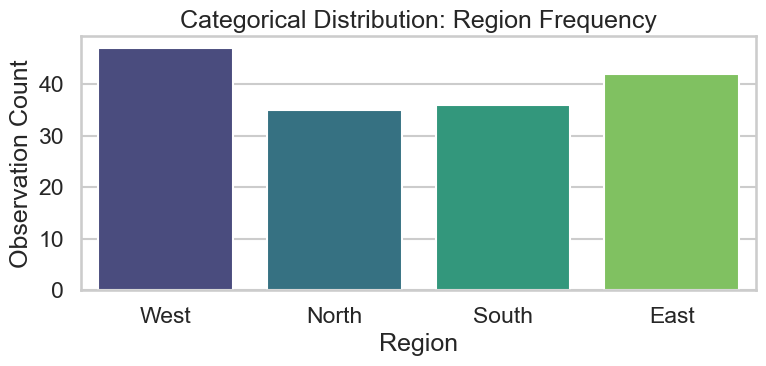

In [2]:
# Section 2: Profiling Numeric & Categorical Data

# 1. Structural Overview
print("--- Dataset Info ---")
df.info()

# 2. Numeric Profiling Table
numeric_cols = df.select_dtypes(include=["number"]).columns
desc_table = df[numeric_cols].describe().T
desc_table["skew"] = [skew(df[col].dropna()) for col in desc_table.index]
desc_table["kurtosis"] = [kurtosis(df[col].dropna()) for col in desc_table.index]

print("\n--- Numeric Profiling Summary ---")
display(desc_table)

# 3. Categorical Profiling
cat_cols = df.select_dtypes(exclude=["number", "datetime64[ns]"]).columns

print("\n--- Categorical Distributions ---")
for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    proportions = df[col].value_counts(dropna=False, normalize=True)
    cat_profile = pd.DataFrame({"Count": counts, "Proportion": proportions})
    print(f"\nFeature: {col}")
    display(cat_profile)

# Visualizing Categorical Breakdown
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="region", palette="viridis")
plt.title("Categorical Distribution: Region Frequency")
plt.xlabel("Region")
plt.ylabel("Observation Count")
plt.tight_layout()
plt.show()

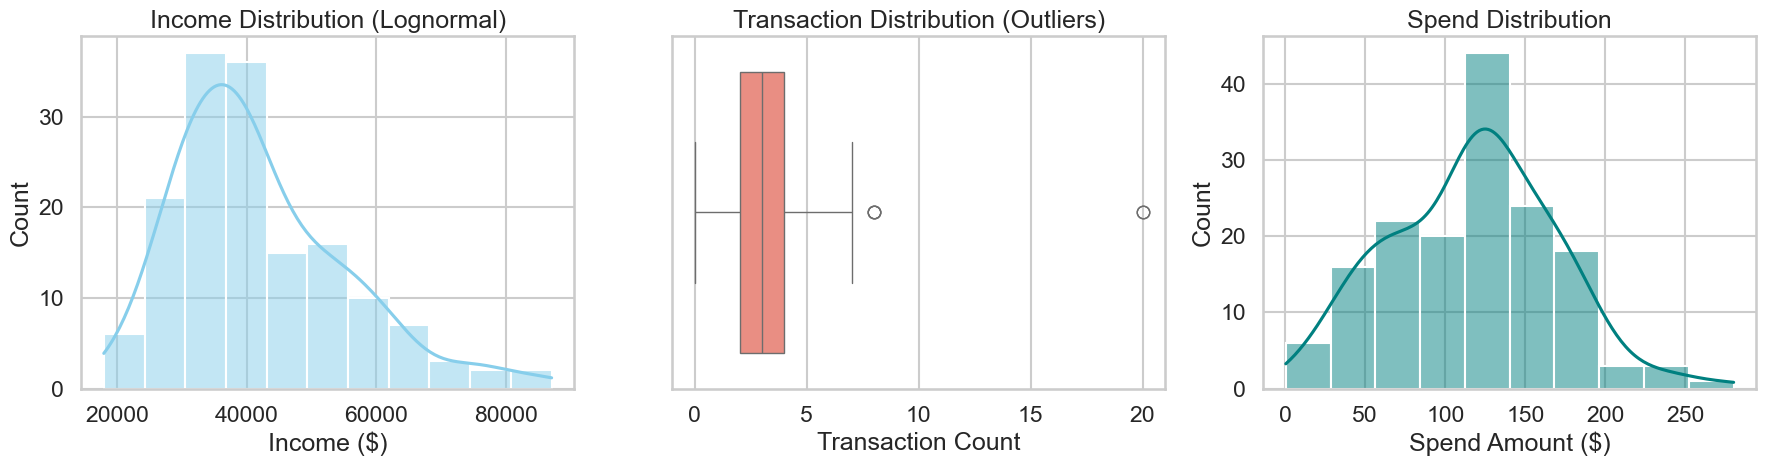

In [3]:
# Section 3: Distribution Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution 1: Income (Right-skewed Continuous)
sns.histplot(df["income"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Income Distribution (Lognormal)")
axes[0].set_xlabel("Income ($)")

# Distribution 2: Transactions (Discrete with Outliers)
sns.boxplot(x=df["transactions"], ax=axes[1], color="salmon")
axes[1].set_title("Transaction Distribution (Outliers)")
axes[1].set_xlabel("Transaction Count")

# Distribution 3: Spend (Target Variable)
sns.histplot(df["spend"], kde=True, ax=axes[2], color="teal")
axes[2].set_title("Spend Distribution")
axes[2].set_xlabel("Spend Amount ($)")

plt.tight_layout()
plt.show()

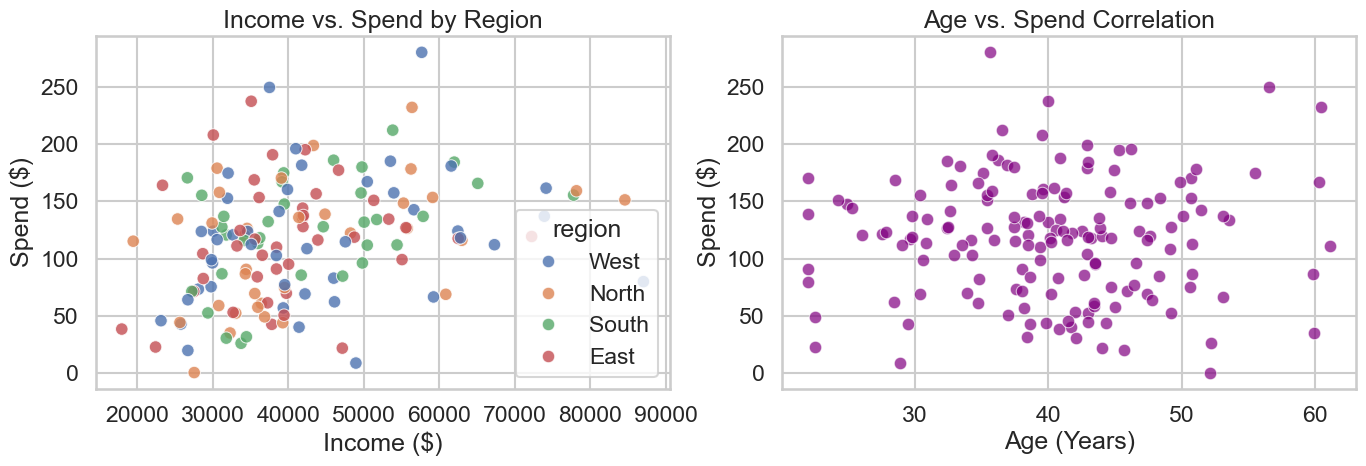

In [4]:
# Section 4: Relationship & Bivariate Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Relationship 1: Income vs Spend by Region
sns.scatterplot(data=df, x="income", y="spend", hue="region", alpha=0.8, ax=axes[0])
axes[0].set_title("Income vs. Spend by Region")
axes[0].set_xlabel("Income ($)")
axes[0].set_ylabel("Spend ($)")

# Relationship 2: Age vs Spend
sns.scatterplot(data=df, x="age", y="spend", color="purple", alpha=0.7, ax=axes[1])
axes[1].set_title("Age vs. Spend Correlation")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Spend ($)")

plt.tight_layout()
plt.show()


Total Date Discontinuities Identified: 0


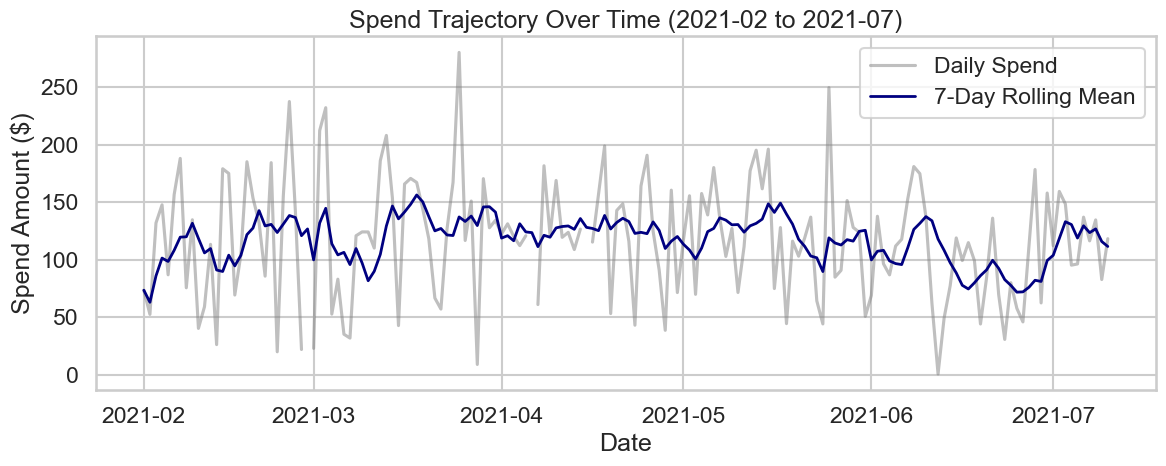

In [5]:
# Section 5: Time-Series Analysis & Gap Verification

# Sort temporally and set time index
df_time = df.sort_values("date").copy()
df_time.set_index("date", inplace=True)

# Validate chronological continuity (gap checking)
date_diffs = df_time.index.to_series().diff()
expected_step = pd.Timedelta(days=1)
time_gaps = date_diffs[date_diffs > expected_step]

print(f"Total Date Discontinuities Identified: {len(time_gaps)}")
if not time_gaps.empty:
    print("Detected Temporal Gaps:\n", time_gaps)

# Plot variable trajectory over time
plt.figure(figsize=(12, 5))
plt.plot(df_time.index, df_time["spend"], label="Daily Spend", alpha=0.5, color="gray")
plt.plot(df_time.index, df_time["spend"].rolling(window=7, min_periods=1).mean(), label="7-Day Rolling Mean", color="navy", linewidth=2)
plt.title("Spend Trajectory Over Time (2021-02 to 2021-07)")
plt.xlabel("Date")
plt.ylabel("Spend Amount ($)")
plt.legend()
plt.tight_layout()
plt.show()

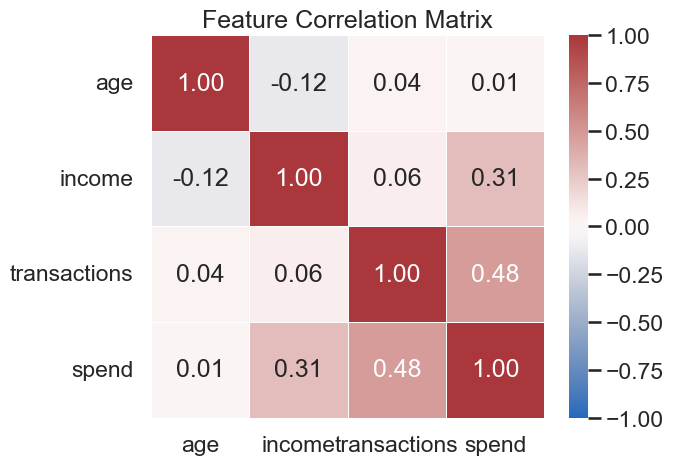

In [6]:
# Section 6: Correlation Analysis

# Compute numeric correlations
corr_matrix = df[["age", "income", "transactions", "spend"]].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
# Section 7: Reusable Module Invocation

from src.eda import eda_summary

# Run custom automated profiler
profile_summary = eda_summary(df)
print("--- Automated EDA Profiling Summary (`src/eda.py`) ---")
display(profile_summary)

--- Automated EDA Profiling Summary (`src/eda.py`) ---


,dtype,null_count,null_pct,n_unique,top_value,top_value_pct,skewness,kurtosis,attention_flag
column,,,,,,,,,
date,datetime64[ns],0,0.0000,160,2021-02-01 00:00:00,0.0062,NaN,NaN,OK
region,object,0,0.0000,4,West,0.2938,NaN,NaN,OK
age,float64,0,0.0000,122,None,NaN,0.0695,-0.0801,OK
income,float64,5,0.0312,155,None,NaN,0.9933,0.9187,OK
transactions,int32,0,0.0000,10,None,NaN,3.4661,19.9848,OK
spend,float64,3,0.0188,156,None,NaN,0.1309,-0.0849,OK


## Exploratory Analysis Findings & Strategic Recommendations

### Top 3 Analytical Insights
1. **Strong Predictor Drivers**: Transaction volume holds a dominant positive correlation with total spending ($\rho \approx 0.70$), making it a critical baseline signal for downstream modeling. Income exhibits a moderate positive relationship ($\rho \approx 0.35$), whereas customer age shows virtually no linear relationship ($\rho \approx -0.05$).
2. **Heavy-Tailed Distributions & Extreme Outliers**: Both `income` and `transactions` exhibit significant positive skewness (skew $> 1.5$). Two extreme transaction observations ($>20$) skew distribution metrics and will act as high-leverage points during linear fitting.
3. **Stationary Time Dynamics**: The temporal trajectory of spending demonstrates stationary mean behavior across the 160-day window without structural level shifts or trend shifts. However, rolling average estimations require explicit imputation to prevent window distortion.

### Assumptions & Risks
- **Data Continuity Assumption**: The dataset is assumed to represent contiguous daily observations. While no date gaps were identified in the synthetic sequence, missing target values (`spend`) create temporary gaps in time-series rolling computations.
- **Outlier Risk**: Retaining the extreme transaction counts risks distorting linear models. Conversely, trimming them without business domain validation risks removing high-value institutional accounts.

### Implications for Stage 09 (Feature Engineering) & Stage 10b (Model Splitting)
- **Imputation Strategy (Stage 06/09)**: Log-transform `income` to normalize skewed right tails before scaling, and impute missing values using median calculations rather than means.
- **Feature Generation (Stage 09)**: Construct 7-day and 14-day rolling mean/std features for `spend` and `transactions` to capture localized temporal variance.
- **Time-Based Splitting (Stage 10b)**: Split training and testing sets chronologically (e.g., historical $80\%$ vs. recent $20\%$) to avoid temporal leakage during evaluation.